# Эксперимент 4: цены bid/ask LOBSTER

Этот ноутбук представляет собой эксперимент над финансовыми данными. Основные естественные ограничения — порядок bid-ask, неотрицательный спред, тождество средней цены, относительный спред и дисбаланс книги заявок.

In [1]:
from pathlib import Path
import os
import random
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.constraints import lobster_bid_ask_constraints
from src.metrics import compare_forecasts
from src.stat_tests import paired_forecast_tests, paired_loss_improvements
from src.nlcr import reconcile_many
from src.plotting import (
    plot_constraint_violations,
    plot_paired_improvement_distributions,
    plot_relative_improvements,
    plot_win_rates,
)

RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "tables").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

## Заготовка данных

In [2]:
def make_demo_lobster_data(n=500, tick_size=0.01, seed=21):
    rng = np.random.default_rng(seed)
    mid = 100 + np.cumsum(rng.normal(0, 0.03, n))
    spread = tick_size * rng.integers(1, 5, n)
    ask_price = mid + spread / 2
    bid_price = mid - spread / 2

    ask_size = rng.lognormal(mean=2.3, sigma=0.35, size=n)
    bid_size = rng.lognormal(mean=2.3, sigma=0.35, size=n)
    relative_spread = spread / mid
    imbalance = (bid_size - ask_size) / (bid_size + ask_size)

    return pd.DataFrame({
        "ask_price_1": ask_price,
        "ask_size_1": ask_size,
        "bid_price_1": bid_price,
        "bid_size_1": bid_size,
        "spread": spread,
        "mid": mid,
        "relative_spread": relative_spread,
        "imbalance": imbalance,
    })


levels = 1
tick_size = 0.01
constraints = lobster_bid_ask_constraints(levels=levels, tick_size=tick_size)
columns = constraints.names
processed_path = PROJECT_ROOT / "data" / "processed" / "lobster" / "lobster_bid_ask_1level.parquet"

if processed_path.exists():
    data = pd.read_parquet(processed_path)
    data_source = f"processed: {processed_path.relative_to(PROJECT_ROOT)}"
    data = data[columns].copy()
else:
    data = make_demo_lobster_data(tick_size=tick_size)
    data_source = "demo generator; run scripts/download_data.py lobster and scripts/prepare_data.py lobster for real data"

print(data_source)
data.head()

processed: data/processed/lobster/lobster_bid_ask_1level.parquet


,ask_price_1,ask_size_1,bid_price_1,bid_size_1,spread,mid,relative_spread,imbalance
0,581.81,100.0,581.69,5.0,0.12,581.750,0.000206,-0.904762
1,581.71,5.0,581.63,34.0,0.08,581.670,0.000138,0.743590
2,581.81,119.0,581.66,134.0,0.15,581.735,0.000258,0.059289
3,581.80,54.0,581.67,124.0,0.13,581.735,0.000223,0.393258
4,581.77,107.0,581.67,94.0,0.10,581.720,0.000172,-0.064677


## Базовые прогнозы

Первая финансовая базовая модель — независимое скользящее среднее.

In [3]:
def rolling_mean_baseline(frame, test_start, windows):
    rows = []
    for t in range(test_start, len(frame)):
        rows.append([frame[col].iloc[t - window:t].mean() for col, window in zip(frame.columns, windows)])
    return pd.DataFrame(rows, columns=frame.columns, index=frame.index[test_start:])


test_size = 100
test_start = len(data) - test_size
windows = [5, 12, 7, 15, 20, 9, 18, 25]
calibration_start = max(windows)

calibration_base = rolling_mean_baseline(data[columns], calibration_start, windows)
y_calibration_true = data.iloc[calibration_start:test_start].reset_index(drop=True)
y_calibration_base = calibration_base.iloc[:test_start - calibration_start].reset_index(drop=True)
calibration_errors = y_calibration_true - y_calibration_base

y_true = data.iloc[test_start:].reset_index(drop=True)
baseline_started = perf_counter()
y_base = rolling_mean_baseline(data[columns], test_start, windows).reset_index(drop=True)
baseline_prediction_seconds = perf_counter() - baseline_started
y_base.head()

,ask_price_1,ask_size_1,bid_price_1,bid_size_1,spread,mid,relative_spread,imbalance
0,577.860,111.333333,577.834286,135.333333,0.044,577.853333,0.000077,0.119547
1,577.862,111.333333,577.834286,154.000000,0.043,577.852222,0.000074,0.142880
2,577.864,119.166667,577.835714,154.000000,0.044,577.851667,0.000074,0.118880
3,577.866,119.166667,577.835714,157.800000,0.042,577.850000,0.000070,0.129475
4,577.860,127.416667,577.827143,161.800000,0.042,577.844444,0.000066,0.128499


## Проекция NLCR и оценивание

In [4]:
METHODS = ("ols", "wls", "shr")
y_reconciled_by_method = {}
failed_by_method = {}
reconciliation_seconds_by_method = {}

for method in METHODS:
    kwargs = {} if method == "ols" else {"errors": calibration_errors}
    reconciliation_started = perf_counter()
    y_reconciled_by_method[method], failed_by_method[method] = reconcile_many(
        y_base,
        constraints,
        method=method,
        **kwargs,
    )
    reconciliation_seconds_by_method[method] = perf_counter() - reconciliation_started

timing_rows = [{
    "experiment": "LOBSTER bid/ask",
    "model": "rolling_mean",
    "method": "base",
    "n_forecasts": len(y_base),
    "baseline_prediction_seconds": baseline_prediction_seconds,
    "reconciliation_seconds": 0.0,
    "total_prediction_seconds": baseline_prediction_seconds,
    "overhead_seconds": 0.0,
    "slowdown_vs_base": 1.0,
    "baseline_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
    "reconciliation_ms_per_forecast": 0.0,
    "total_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
    "failed": 0,
}]
for method in METHODS:
    reconciliation_seconds = reconciliation_seconds_by_method[method]
    total_seconds = baseline_prediction_seconds + reconciliation_seconds
    timing_rows.append({
        "experiment": "LOBSTER bid/ask",
        "model": "rolling_mean",
        "method": method,
        "n_forecasts": len(y_base),
        "baseline_prediction_seconds": baseline_prediction_seconds,
        "reconciliation_seconds": reconciliation_seconds,
        "total_prediction_seconds": total_seconds,
        "overhead_seconds": reconciliation_seconds,
        "slowdown_vs_base": total_seconds / baseline_prediction_seconds,
        "baseline_ms_per_forecast": 1000.0 * baseline_prediction_seconds / len(y_base),
        "reconciliation_ms_per_forecast": 1000.0 * reconciliation_seconds / len(y_base),
        "total_ms_per_forecast": 1000.0 * total_seconds / len(y_base),
        "failed": len(failed_by_method[method]),
    })

timing_results = pd.DataFrame(timing_rows)
timing_results.to_csv(RESULTS_DIR / "tables" / "lobster_bid_ask_timing.csv", index=False)
failed_by_method

# Keep the OLS projection under the historical variable name for compatibility
# with existing narrative cells and quick inspection.
y_reconciled = y_reconciled_by_method["ols"]
y_reconciled.head()

,ask_price_1,ask_size_1,bid_price_1,bid_size_1,spread,mid,relative_spread,imbalance
0,577.868159,111.333234,577.830254,135.333415,0.037905,577.849206,0.000066,0.097298
1,577.868455,111.333412,577.830550,153.999943,0.037905,577.849503,0.000066,0.160803
2,577.869841,119.166702,577.831079,153.999972,0.038762,577.850460,0.000067,0.127517
3,577.869619,119.166708,577.831524,157.799969,0.038095,577.850571,0.000066,0.139487
4,577.863339,127.416629,577.824386,161.800029,0.038952,577.843862,0.000067,0.118885


## Время выполнения

Ниже показано чистое время базового прогноза, накладные расходы NLCR и полное время `baseline + reconciliation`. Для честного сравнения все значения нормированы на один прогноз.

,method,n_forecasts,"baseline, ms/forecast","NLCR overhead, ms/forecast","total, ms/forecast",slowdown vs baseline,failed
0,base,100,0.570,0.000,0.570,1.0x,0
1,ols,100,0.570,5.207,5.776,10.1x,0
2,wls,100,0.570,57.120,57.690,101.3x,0
3,shr,100,0.570,56.864,57.433,100.8x,0


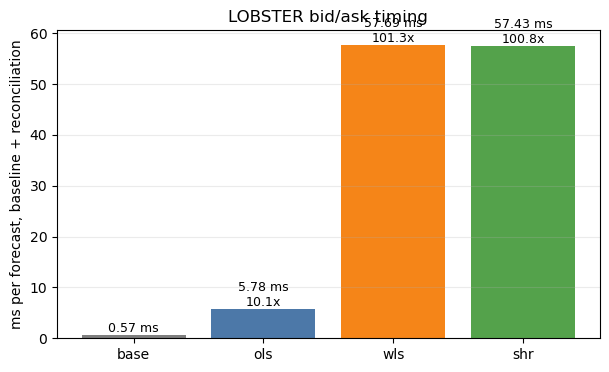

In [5]:
timing_view = timing_results.copy()
timing_view = timing_view[[
    "method", "n_forecasts", "baseline_ms_per_forecast",
    "reconciliation_ms_per_forecast", "total_ms_per_forecast",
    "slowdown_vs_base", "failed",
]].rename(columns={
    "baseline_ms_per_forecast": "baseline, ms/forecast",
    "reconciliation_ms_per_forecast": "NLCR overhead, ms/forecast",
    "total_ms_per_forecast": "total, ms/forecast",
    "slowdown_vs_base": "slowdown vs baseline",
})

display(
    timing_view.style.format({
        "baseline, ms/forecast": "{:.3f}",
        "NLCR overhead, ms/forecast": "{:.3f}",
        "total, ms/forecast": "{:.3f}",
        "slowdown vs baseline": "{:.1f}x",
    })
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_data = timing_results.set_index("method")["total_ms_per_forecast"].reindex(["base", "ols", "wls", "shr"])
bars = ax.bar(plot_data.index, plot_data.values, color=["#7E7E7E", "#4C78A8", "#F58518", "#54A24B"])
ax.set_ylabel("ms per forecast, baseline + reconciliation")
ax.set_title("LOBSTER bid/ask timing")
ax.grid(axis="y", alpha=0.25)
for bar, method in zip(bars, plot_data.index):
    row = timing_results[timing_results["method"] == method].iloc[0]
    label = f"{row['total_ms_per_forecast']:.2f} ms"
    if method != "base":
        label += f"\n{row['slowdown_vs_base']:.1f}x"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=9)
fig.savefig(RESULTS_DIR / "figures" / "lobster_bid_ask_timing.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)


## Метрики и графики

In [6]:
metric_tables = []
stat_test_tables = []
loss_improvement_tables = []

for method, y_method in y_reconciled_by_method.items():
    method_metrics = compare_forecasts(y_true, y_base, y_method, constraints)
    method_metrics["p_reconciled_better"] = method_metrics.attrs["p_reconciled_better"]
    method_metrics["method"] = method_metrics["forecast"].where(method_metrics["forecast"] == "base", method)
    method_metrics = method_metrics[method_metrics["forecast"] != "base"]
    metric_tables.append(method_metrics)

    method_stat_tests = paired_forecast_tests(y_true, y_base, y_method)
    method_stat_tests.insert(0, "method", method)
    stat_test_tables.append(method_stat_tests)

    method_loss_improvements = paired_loss_improvements(y_true, y_base, y_method)
    method_loss_improvements.insert(0, "method", method)
    loss_improvement_tables.append(method_loss_improvements)

base_metrics = compare_forecasts(y_true, y_base, y_reconciled_by_method["ols"], constraints)
base_metrics = base_metrics[base_metrics["forecast"] == "base"].copy()
base_metrics["p_reconciled_better"] = pd.NA
base_metrics["method"] = "base"

metrics = pd.concat([base_metrics, *metric_tables], ignore_index=True)
metrics.to_csv(RESULTS_DIR / "tables" / "lobster_bid_ask_metrics.csv", index=False)

stat_tests = pd.concat(stat_test_tables, ignore_index=True)
stat_tests.to_csv(RESULTS_DIR / "tables" / "lobster_bid_ask_stat_tests.csv", index=False)

loss_improvements = pd.concat(loss_improvement_tables, ignore_index=True)
loss_improvements.to_csv(RESULTS_DIR / "tables" / "lobster_bid_ask_loss_improvements.csv", index=False)

display(stat_tests)
metrics

,method,metric,base_loss,nlcr_loss,mean_improvement,relative_improvement_pct,win_rate,wilcoxon_stat,wilcoxon_p,sign_p,bootstrap_ci_low,bootstrap_ci_high,n_observations,n_non_ties
0,ols,mae,65.586614,65.585596,0.001019,0.001553,0.52,2628.0,0.361614,0.382177,-0.003328,0.003536,100,100
1,ols,rmse,155.874326,155.874315,0.000010,0.000007,0.45,2501.0,0.532883,0.864373,-0.000003,0.000029,100,100
2,ols,smape,0.437012,0.417641,0.019371,4.432617,0.65,3643.0,0.000061,0.001759,0.008922,0.030676,100,100
3,wls,mae,65.586614,62.022913,3.563701,5.433580,0.60,3126.0,0.019394,0.028444,1.087414,7.890493,100,100
4,wls,rmse,155.874326,146.922584,8.951742,5.742922,0.60,3139.0,0.017381,0.028444,2.831992,19.212935,100,100
5,wls,smape,0.437012,0.429619,0.007393,1.691704,0.59,3160.0,0.014506,0.044313,0.003374,0.013591,100,100
6,shr,mae,65.586614,61.939232,3.647383,5.561169,0.60,3120.0,0.020388,0.028444,1.070469,8.136095,100,100
7,shr,rmse,155.874326,146.811158,9.063167,5.814407,0.60,3134.0,0.018133,0.028444,2.718941,19.623869,100,100
8,shr,smape,0.437012,0.429924,0.007088,1.621995,0.60,3114.0,0.021425,0.028444,0.002892,0.013343,100,100


,forecast,mae,rmse,smape,constraint_violation,p_reconciled_better,method
0,base,65.586614,219.368210,0.437012,1.620388e-01,<NA>,base
1,nlcr,65.585596,219.368217,0.417641,2.025535e-11,0.45,ols
2,nlcr,62.022913,219.600877,0.429619,1.401295e-11,0.6,wls
3,nlcr,61.939232,219.695870,0.429924,1.387453e-11,0.6,shr


## Статистические тесты

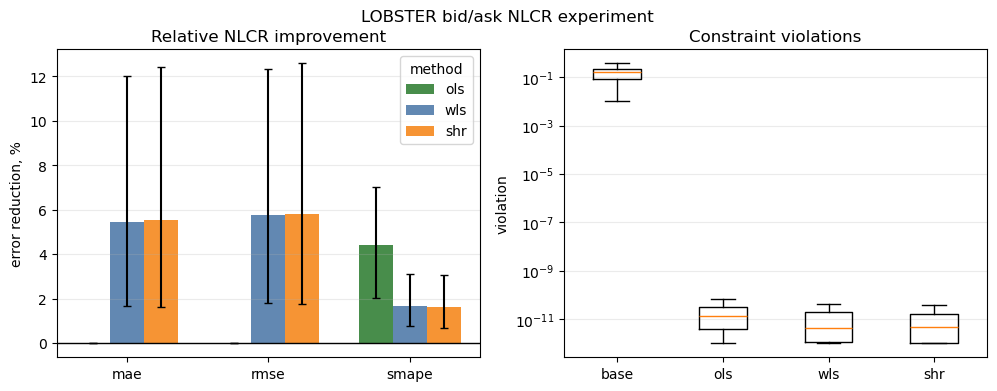

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_relative_improvements(stat_tests, ax=axes[0])
plot_constraint_violations(y_base, y_reconciled_by_method, constraints, ax=axes[1])
fig.suptitle("LOBSTER bid/ask NLCR experiment")
fig.savefig(RESULTS_DIR / "figures" / "lobster_bid_ask_experiment.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

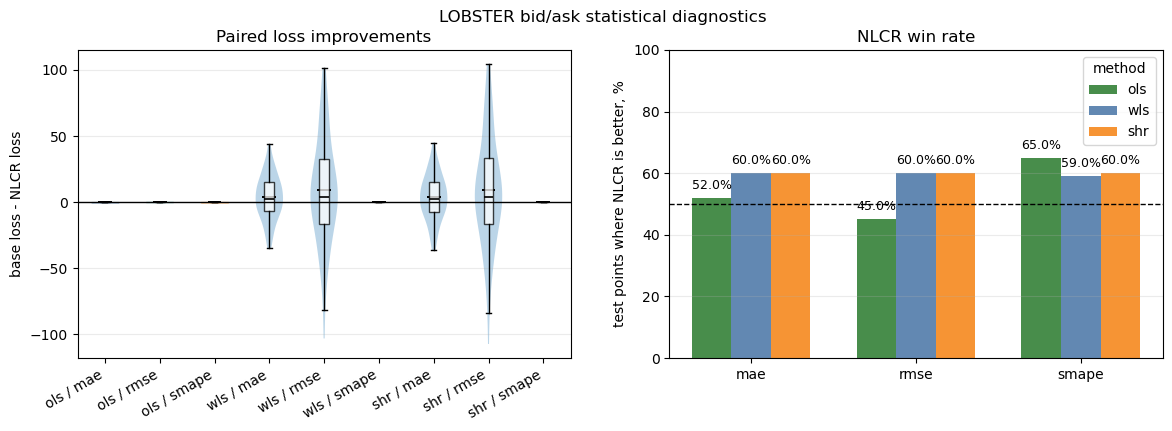

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_paired_improvement_distributions(loss_improvements, ax=axes[0])
plot_win_rates(stat_tests, ax=axes[1])
fig.suptitle("LOBSTER bid/ask statistical diagnostics")
fig.savefig(RESULTS_DIR / "figures" / "lobster_bid_ask_stat_tests.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

## Выводы по результатам эксперимента

- NLCR устраняет рыночные нарушения bid/ask-вектора: mean violation снижается с `0.162` до порядка `1e-11`.
- `wls` и `shr` улучшают MAE примерно на `5.4-5.6%` и SMAPE на `1.6-1.7%`, но слегка ухудшают RMSE на `0.11-0.15%`. Поэтому преимущества weighted reconciliation зависят от выбранной функции потерь.
- `ols` почти не меняет MAE/RMSE, но улучшает SMAPE на `4.43%`. Это показывает, что простая евклидова проекция полезна для относительных ошибок, но хуже учитывает разный масштаб LOB-переменных.
- В этой задаче weighted reconciliation выглядит наиболее естественным, поскольку цены, размеры заявок и derived indicators имеют резко разные масштабы и дисперсии.

- Baseline требует `0.57` мс на прогноз. Полное время `baseline + NLCR` составляет `5.78` мс для `ols`, `57.69` мс для `wls` и `57.43` мс для `shr` (`10.1x`, `101.3x` и `100.8x`). В latency-sensitive постановке `ols` значительно дешевле weighted-вариантов.